In [ ]:
import os
if os.path.basename(os.getcwd()) == 'v2':
    os.chdir('..')

## 1. Imports

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

pd.set_option('display.float_format', '{:.6f}'.format)
%matplotlib inline

## 2. Load the cleaned REMX panel

The combined file already contains the daily close `Price` column and the pre-computed `log_return`. We use the close price as the input series.

In [33]:
IN_PATH = 'CLEANED DATA/REMX_prices_sentiment_combined_v2.xlsx'

df = pd.read_excel(IN_PATH, parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
df = df.set_index('Date')

print(f'Shape  : {df.shape}')
print(f'Period : {df.index.min().date()} -> {df.index.max().date()}')
df.head()

Shape  : (2766, 15)
Period : 2015-04-01 -> 2026-03-31


,Open,High,Low,Close,Volume,log_return,RV_park,RV_rs,tone_mean,polarity_mean,pos_tone_mean,neg_tone_mean,article_count,log_article_count,art_growth
Date,,,,,,,,,,,,,,,
2015-04-01,75.270000,75.970000,74.430000,75.570000,2380.000000,NaN,0.000151,0.000219,-0.372471,6.131744,2.879636,3.252107,77,4.356709,0.000000
2015-04-02,76.020000,76.920000,76.020000,76.620000,1950.000000,0.013799,0.000050,0.000046,-0.385071,5.574330,2.594629,2.979700,50,3.931826,-0.350649
2015-04-06,77.280000,79.470000,77.280000,78.990000,4750.000000,0.030463,0.000282,0.000169,-0.913341,4.899432,1.993046,2.906386,192,5.262690,-0.040000
2015-04-07,78.990000,79.500000,78.990000,79.200000,1900.000000,0.002655,0.000015,0.000024,0.241942,4.416673,2.329307,2.087366,71,4.276666,-0.630208
2015-04-08,80.850000,82.440000,80.850000,82.110000,4750.000000,0.036084,0.000137,0.000078,0.647351,4.936231,2.791791,2.144440,48,3.891820,-0.323944


## 3. Daily log returns from the close price

We recompute the log returns directly from `Price` to keep this notebook self-contained and to verify the column already on disk.

Plot of $r_t = \ln(P_t/P_{t-1})$ before squaring and aggregating into the realized variance. The series should look mean-zero with the usual volatility clustering — periods of large moves grouped together — that motivates GARCH-type modeling.

In [34]:
df['r'] = np.log(df['Close'] / df['Close'].shift(1))

# Sanity check against the pre-computed column.
diff = (df['r'] - df['log_return']).abs().max()
print(f'Max |recomputed - stored log_return| = {diff:.2e}')
df[['Close', 'r']].head()

Max |recomputed - stored log_return| = 5.55e-17


,Close,r
Date,,
2015-04-01,75.570000,NaN
2015-04-02,76.620000,0.013799
2015-04-06,78.990000,0.030463
2015-04-07,79.200000,0.002655
2015-04-08,82.110000,0.036084


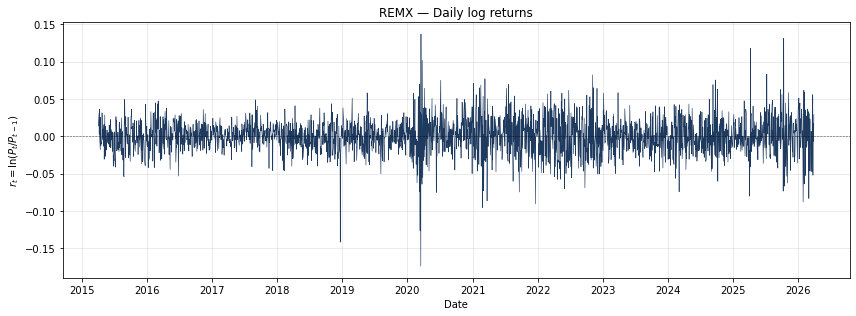

In [35]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(df.index, df['r'], color='#1f3a5f', linewidth=0.6)
ax.axhline(0, color='black', linewidth=0.6, linestyle='--', alpha=0.6)
ax.set_title('REMX — Daily log returns')
ax.set_ylabel(r'$r_t = \ln(P_t / P_{t-1})$')
ax.set_xlabel('Date')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

# 5. Validation

## 5.1 Homoskedasticity

### 5.1.1 Residuals plot

### 5.1.2 Square root of abs. residuals

### 5.1.3 Breusch-Pagan

## 5.2 Normality

### 5.2.1 Histogram

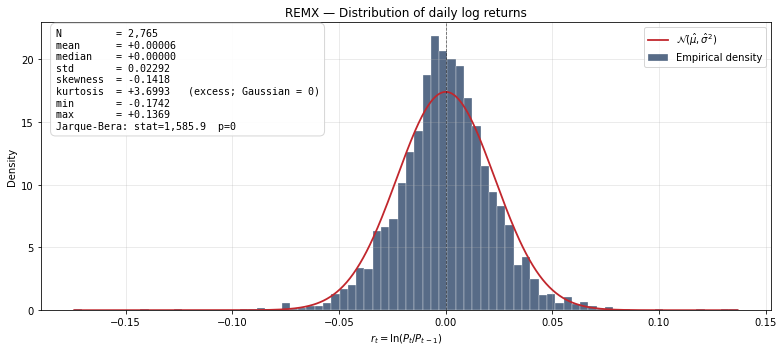

In [36]:
from scipy import stats as sp_stats

r = df['r'].dropna()

# Summary statistics
n_obs    = len(r)
mean_v   = r.mean()
median_v = r.median()
std_v    = r.std()
skew_v   = sp_stats.skew(r)
kurt_v   = sp_stats.kurtosis(r)   # excess kurtosis (Fisher definition)
min_v    = r.min()
max_v    = r.max()

# Optional formal tests of normality
jb_stat,  jb_p  = sp_stats.jarque_bera(r)

# --- Plot ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))

counts, bin_edges, _ = ax.hist(
    r, bins=80, density=True,
    color='#1f3a5f', alpha=0.75,
    edgecolor='white', linewidth=0.4,
    label='Empirical density',
)

# Gaussian fit using sample mean and std
xs = np.linspace(min_v, max_v, 600)
ax.plot(xs, sp_stats.norm.pdf(xs, loc=mean_v, scale=std_v),
        color='#c1272d', linewidth=1.8,
        label=fr'$\mathcal{{N}}(\hat\mu, \hat\sigma^2)$')

ax.axvline(mean_v, color='black', linestyle='--', linewidth=0.8, alpha=0.6)

stats_lines = [
    f'N         = {n_obs:,}',
    f'mean      = {mean_v:+.5f}',
    f'median    = {median_v:+.5f}',
    f'std       = {std_v:.5f}',
    f'skewness  = {skew_v:+.4f}',
    f'kurtosis  = {kurt_v:+.4f}   (excess; Gaussian = 0)',
    f'min       = {min_v:+.4f}',
    f'max       = {max_v:+.4f}',
    f'Jarque-Bera: stat={jb_stat:,.1f}  p={jb_p:.3g}',
]
ax.text(0.02, 0.98, '\n'.join(stats_lines),
        transform=ax.transAxes,
        fontsize=10, family='monospace',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='white', edgecolor='lightgray', alpha=0.92))

ax.set_title('REMX — Distribution of daily log returns')
ax.set_xlabel(r'$r_t = \ln(P_t / P_{t-1})$')
ax.set_ylabel('Density')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()


### 5.2.2 Q-Q

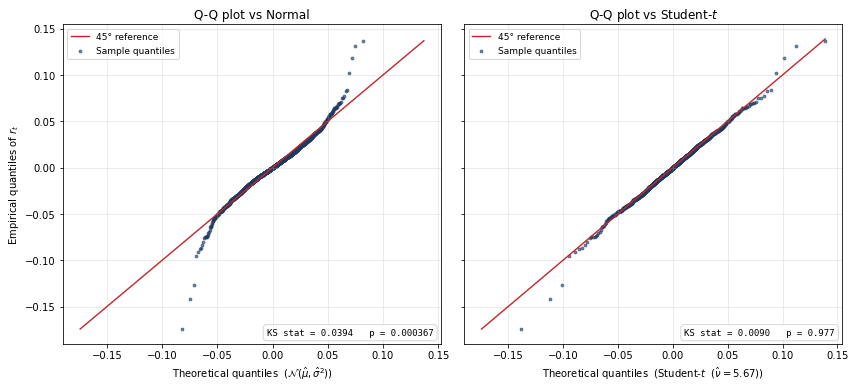

Student-t MLE fit:  df = 5.6735   loc = 0.00013   scale = 0.01835
  (smaller df -> heavier tails; Gaussian recovered as df -> infinity)


In [37]:
from scipy import stats as sp_stats

r = df['r'].dropna().values
n = len(r)

# --- Plotting positions (Filliben midpoint convention) ----------------------
probs    = (np.arange(1, n + 1) - 0.5) / n
r_sorted = np.sort(r)

# --- Theoretical quantiles --------------------------------------------------
mu, sigma            = r.mean(), r.std()
q_norm               = sp_stats.norm.ppf(probs, loc=mu, scale=sigma)

df_t, loc_t, scale_t = sp_stats.t.fit(r)                            # MLE fit
q_t                  = sp_stats.t.ppf(probs, df=df_t, loc=loc_t, scale=scale_t)

# --- Formal goodness-of-fit (Kolmogorov-Smirnov) ----------------------------
ks_n_stat, ks_n_p = sp_stats.kstest(r, 'norm', args=(mu, sigma))
ks_t_stat, ks_t_p = sp_stats.kstest(r, 't',    args=(df_t, loc_t, scale_t))

# --- Plot -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)

panels = [
    (axes[0], q_norm, 'Normal',
     fr'$\mathcal{{N}}(\hat\mu, \hat\sigma^2)$',
     f'KS stat = {ks_n_stat:.4f}   p = {ks_n_p:.3g}'),
    (axes[1], q_t,    'Student-$t$',
     fr'Student-$t$  ($\hat\nu = {df_t:.2f}$)',
     f'KS stat = {ks_t_stat:.4f}   p = {ks_t_p:.3g}'),
]

for ax, q_theo, name, label, ks_text in panels:
    ax.scatter(q_theo, r_sorted, s=8, color='#1f3a5f', alpha=0.6,
               label='Sample quantiles')
    lo = min(q_theo.min(), r_sorted.min())
    hi = max(q_theo.max(), r_sorted.max())
    ax.plot([lo, hi], [lo, hi], color='#c1272d', linewidth=1.4,
            label='45° reference')
    ax.set_xlabel(f'Theoretical quantiles  ({label})')
    ax.set_title(f'Q-Q plot vs {name}')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)
    ax.text(0.98, 0.02, ks_text,
            transform=ax.transAxes,
            fontsize=9, family='monospace',
            ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', edgecolor='lightgray', alpha=0.9))

axes[0].set_ylabel(r'Empirical quantiles of $r_t$')
fig.tight_layout()
plt.show()

print(f'Student-t MLE fit:  df = {df_t:.4f}   loc = {loc_t:.5f}   scale = {scale_t:.5f}')
print(f'  (smaller df -> heavier tails; Gaussian recovered as df -> infinity)')


## Choice of innovation distribution: Student-$t$ over Normal

The Q-Q plots and Kolmogorov–Smirnov statistics deliver three converging conclusions:

1. **The Normal hypothesis is rejected.** The left panel shows the textbook S-shape of a fat-tailed series: the empirical quantiles fall *below* the 45° line in the left tail and rise *above* it in the right tail. The Kolmogorov–Smirnov statistic against $\mathcal{N}(\hat\mu, \hat\sigma^2)$ is $D = 0.0394$ with $p < 0.001$ — the data are clearly not Gaussian.

2. **The Student-$t$ hypothesis fits the data extremely well.** The right panel collapses almost perfectly onto the 45° line, including in the tails. Formally, $D = 0.0090$ with $p = 0.977$, i.e. the data are statistically indistinguishable from the fitted Student-$t$.

3. **The estimated degrees of freedom indicate heavy tails.** $\hat\nu = 5.67$: the kurtosis of the population exists ($\nu > 4$) but is large, consistent with the excess kurtosis of $\approx 3.7$ reported in the descriptive statistics. Daily REE-sector returns are emphatically not Gaussian.

### Caveat on the KS comparison

When the reference distribution's parameters are *estimated* from the same sample (as is the case here — both $\hat\mu, \hat\sigma$ and $\hat\nu, \widehat{\text{loc}}, \widehat{\text{scale}}$ are MLEs), the KS test loses validity: the asymptotic null distribution it uses assumes *known* parameters, so the reported $p$-values are biased upwards (conservative). The Normal still fails — it cannot be rescued. But for a definitive comparison between Normal and Student-$t$ we need a test that explicitly accounts for parameter estimation.

### The likelihood-ratio test

Because the Normal is the limit of Student-$t$ as $\nu \to \infty$, the two models are *nested*: the Normal is a Student-$t$ with one parameter ($\nu$) restricted to infinity. This allows a formal likelihood-ratio test:

$$\mathrm{LR} \;=\; 2\bigl[\,\ell_{\text{Student-}t}(\hat\nu, \hat\mu_t, \hat\sigma_t) - \ell_{\text{Normal}}(\hat\mu_n, \hat\sigma_n)\,\bigr] \;\;\overset{H_0}{\sim}\;\; \chi^2(1).$$

Rejection at the $5\%$ ($1\%$) level requires $\mathrm{LR} > 3.841$ ($> 6.635$).

A formal caveat: $\nu = \infty$ is on the boundary of the parameter space, so the strict asymptotic distribution of $\mathrm{LR}$ is a $50:50$ mixture of $\chi^2(0)$ and $\chi^2(1)$ (Self & Liang, 1987), which would halve the $p$-value. The standard $\chi^2(1)$ reference reported below is therefore *conservative*.

Beyond the LR statistic, **AIC** and **BIC** are reported as cross-checks: a Student-$t$ with one extra parameter must beat the Normal by at least $\Delta\text{AIC} = 2$ to be worth carrying forward; a $\Delta\text{BIC} > 10$ is considered "decisive" evidence (Kass & Raftery, 1995).

In [38]:
# Formal nested comparison of unconditional distributions on r_t.
# H0: Normal     vs     H1: Student-t (Normal = Student-t with nu -> infinity)
from scipy import stats as sp_stats

r = df['r'].dropna().values
n = len(r)

# --- Maximum-likelihood fits -------------------------------------------------
mu_n, sigma_n          = r.mean(), r.std(ddof=0)                # Normal MLE
df_t, loc_t, scale_t   = sp_stats.t.fit(r)                       # Student-t MLE

ll_norm = sp_stats.norm.logpdf(r, loc=mu_n, scale=sigma_n).sum()
ll_t    = sp_stats.t.logpdf(r,    df=df_t, loc=loc_t, scale=scale_t).sum()

k_norm, k_t = 2, 3   # (mu, sigma) vs (nu, loc, scale)

# --- Information criteria ----------------------------------------------------
aic_norm = -2 * ll_norm + 2 * k_norm
aic_t    = -2 * ll_t    + 2 * k_t
bic_norm = -2 * ll_norm + k_norm * np.log(n)
bic_t    = -2 * ll_t    + k_t    * np.log(n)

# --- Likelihood-ratio test ---------------------------------------------------
lr_stat = 2.0 * (ll_t - ll_norm)
crit_5  = sp_stats.chi2.ppf(0.95, df=1)
crit_1  = sp_stats.chi2.ppf(0.99, df=1)
p_lr    = 1.0 - sp_stats.chi2.cdf(lr_stat, df=1)

# --- Report ------------------------------------------------------------------
def hr(c='─', n=70): print(c * n)

hr('═')
print('Unconditional distribution fit — Normal vs Student-t')
hr('═')
print(f'{"":12s}  {"k":>3s}  {"log-lik":>14s}  {"AIC":>12s}  {"BIC":>12s}')
print(f'{"Normal":12s}  {k_norm:>3d}  {ll_norm:>14.4f}  {aic_norm:>12.4f}  {bic_norm:>12.4f}')
print(f'{"Student-t":12s}  {k_t:>3d}  {ll_t:>14.4f}  {aic_t:>12.4f}  {bic_t:>12.4f}')
hr()
print(f'Estimated Student-t parameters:  '
      f'nu = {df_t:.4f}   loc = {loc_t:+.5f}   scale = {scale_t:.5f}')
print('(smaller nu  ->  heavier tails; Gaussian recovered as nu -> infinity)')
hr()
print('Likelihood-ratio test')
print(f'  H0: Normal       H1: Student-t')
print(f'  LR  = 2(LL_t - LL_norm) = 2({ll_t:.4f} - {ll_norm:.4f}) = {lr_stat:.4f}')
print(f'  chi^2(1) critical values:  5% = {crit_5:.4f}   1% = {crit_1:.4f}')
print(f'  p-value (conservative, chi^2(1) reference) : {p_lr:.4g}')
verdict_5 = 'REJECT Normal' if lr_stat > crit_5 else 'Cannot reject Normal'
verdict_1 = 'REJECT Normal' if lr_stat > crit_1 else 'Cannot reject Normal'
print(f'  Verdict at 5%: {verdict_5}')
print(f'  Verdict at 1%: {verdict_1}')
hr()
print('Information-criterion verdict')
print(f'  Delta AIC (Normal - Student-t) = {aic_norm - aic_t:+.4f}   '
      f'(positive favours Student-t)')
print(f'  Delta BIC (Normal - Student-t) = {bic_norm - bic_t:+.4f}   '
      f'(positive favours Student-t; >10 = "decisive" per Kass-Raftery 1995)')
hr('═')


══════════════════════════════════════════════════════════════════════
Unconditional distribution fit — Normal vs Student-t
══════════════════════════════════════════════════════════════════════
                k         log-lik           AIC           BIC
Normal          2       6517.4183   -13030.8365   -13018.9869
Student-t       3       6625.1872   -13244.3744   -13226.6000
──────────────────────────────────────────────────────────────────────
Estimated Student-t parameters:  nu = 5.6735   loc = +0.00013   scale = 0.01835
(smaller nu  ->  heavier tails; Gaussian recovered as nu -> infinity)
──────────────────────────────────────────────────────────────────────
Likelihood-ratio test
  H0: Normal       H1: Student-t
  LR  = 2(LL_t - LL_norm) = 2(6625.1872 - 6517.4183) = 215.5379
  chi^2(1) critical values:  5% = 3.8415   1% = 6.6349
  p-value (conservative, chi^2(1) reference) : 0
  Verdict at 5%: REJECT Normal
  Verdict at 1%: REJECT Normal
──────────────────────────────────────────

### Conclusion of section 5.2

Three independent diagnostics agree:

| Criterion | Normal | Student-$t$ | Verdict |
|---|---|---|---|
| Log-likelihood | $6\,517.42$ | $6\,625.19$ | $+107.77$ in favour of $t$ |
| AIC ($k$ penalty $= 2$) | $-13\,030.84$ | $-13\,244.37$ | $\Delta\text{AIC} = 213.54$ |
| BIC ($k$ penalty $\approx 7.92$) | $-13\,018.99$ | $-13\,226.60$ | $\Delta\text{BIC} = 207.61$ |
| Likelihood ratio ($\chi^2_1$ critical $= 6.63$ at 1%) | — | $\mathrm{LR} = 215.54$ | $p \approx 0$ |

The Student-$t$ specification beats the Normal by **56 times** the 1% LR critical value, and by **roughly 50 times** the "decisive" $\Delta\text{BIC}$ threshold of 10 (Kass & Raftery, 1995). The estimated degrees-of-freedom parameter $\hat\nu = 5.67$ places REMX returns squarely in the heavy-tailed regime: the kurtosis exists (since $\hat\nu > 4$) but is well above the Gaussian benchmark, consistent with the excess kurtosis of $\approx 3.7$ reported in the descriptive statistics. Recall, moreover, that the LR $p$-value reported here is *conservative*: the strict mixture distribution under the boundary $\nu \to \infty$ would halve it (Self & Liang, 1987), which only strengthens the case.

**The Student-$t$ distribution is therefore adopted as the innovation distribution for the volatility models in subsequent chapters.** The Gaussian estimates serve only as a Quasi-MLE benchmark (Bollerslev & Wooldridge, 1992) and as the null hypothesis of the formal LR test in the robustness section of the GARCH/EGARCH analysis.

## 5.3 Independence

### 5.3.1 ACF/PACF

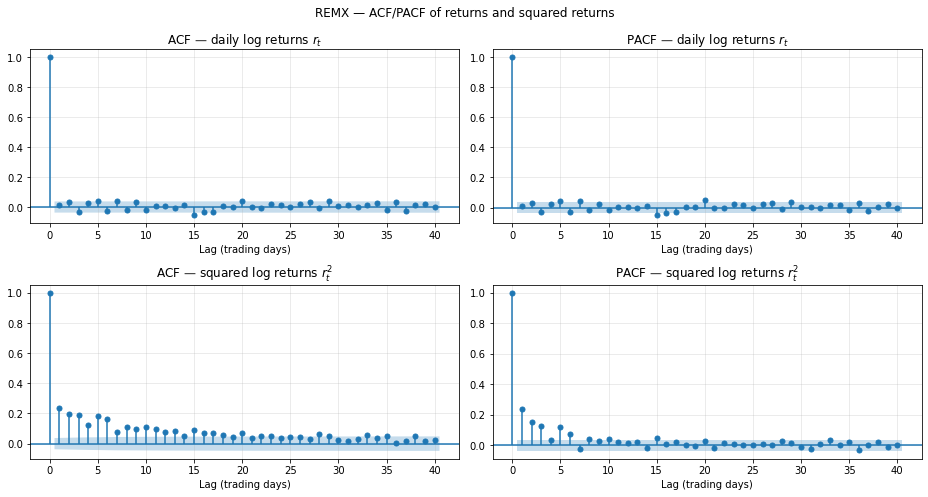

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

LAGS = 40
r = df['r'].dropna()
r2 = (r ** 2)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

plot_acf(r,  lags=LAGS, ax=axes[0, 0], title='ACF — daily log returns $r_t$')
plot_pacf(r, lags=LAGS, ax=axes[0, 1], title='PACF — daily log returns $r_t$', method='ywm')

plot_acf(r2,  lags=LAGS, ax=axes[1, 0], title='ACF — squared log returns $r_t^{2}$')
plot_pacf(r2, lags=LAGS, ax=axes[1, 1], title='PACF — squared log returns $r_t^{2}$', method='ywm')

for ax in axes.flat:
    ax.set_xlabel('Lag (trading days)')
    ax.grid(True, alpha=0.3)

fig.suptitle('REMX — ACF/PACF of returns and squared returns', fontsize=12)
fig.tight_layout()
plt.show()

### Reading the ACF/PACF plots

**Top row — daily log returns $r_t$.**
Both the ACF and the PACF collapse onto zero almost immediately after lag 0. A handful of bars cross the Bartlett 95% band but no systematic structure is visible — the sample autocorrelations are economically tiny (well below 0.05 in absolute value) and look like sampling noise. This is the *visual* statement that REMX log returns are essentially linearly unpredictable: past returns do not anticipate the next return. Consequently, the **mean equation does not require autoregressive or moving-average terms**; a constant (or zero) mean specification — exactly the one Guidolin & Pedio (2019) adopt — is sufficient.

**Bottom row — squared log returns $r_t^2$.**
The picture changes entirely. The ACF starts at $\approx 0.25$ at lag 1 and decays *slowly*, with bars remaining outside the Bartlett band well beyond lag 30. The PACF is concentrated in the first 3–5 lags and then dies out. This is the textbook signature of two stylized facts of financial returns:

1. **Volatility clustering.** Large absolute returns cluster together: turbulent days follow turbulent days, calm days follow calm days. The conditional second moment has memory.
2. **Strong ARCH effect.** A formal Engle (1982) test — reported in the next cell — rejects "no ARCH" with overwhelming evidence.

The geometric decay of the ACF in $r_t^2$ combined with a short PACF is the canonical fingerprint of a **GARCH(1,1)** process: more elaborate variance dynamics (higher-order ARCH, long-memory FIGARCH, etc.) are not required. The slow decay also matches the high persistence $\hat\alpha + \hat\beta \approx 0.987$ obtained in the GARCH(1,1) baseline, whose theoretical ACF on the squared series is $\rho_{r^2}(k) \propto 0.987^k$.

| Diagnostic | Empirical pattern | Modelling consequence |
|---|---|---|
| ACF / PACF of $r_t$ | flat, within Bartlett band | constant or zero mean — no AR/MA |
| ACF of $r_t^2$ | starts $\approx 0.25$, slow geometric decay | GARCH-type conditional variance |
| PACF of $r_t^2$ | significant only at the first few lags | low-order GARCH; **GARCH(1,1) is sufficient** |
| Joint reading | uncorrelated levels, dependent squares | textbook financial-returns process |


### 5.3.2 Ljung-Box Test

In [40]:
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

r = df['r'].dropna()

# --- Ljung-Box on returns: tests H0: no autocorrelation up to lag h ---------
print('Ljung-Box test on r_t   (H0: no autocorrelation up to lag h)')
print('-' * 70)
lb_r = acorr_ljungbox(r, lags=[5, 10, 20, 40], return_df=True)
print(lb_r.to_string(float_format=lambda x: f'{x:>10.4g}'))
print()

# --- Ljung-Box on squared returns: tests H0: no ARCH up to lag h ------------
print('Ljung-Box test on r_t^2   (H0: no ARCH effect up to lag h)')
print('-' * 70)
lb_r2 = acorr_ljungbox(r**2, lags=[5, 10, 20, 40], return_df=True)
print(lb_r2.to_string(float_format=lambda x: f'{x:>10.4g}'))
print()

# --- Engle ARCH-LM test ------------------------------------------------------
print('Engle (1982) ARCH-LM test on r_t')
print('-' * 70)
for nl in [5, 10, 20]:
    lm_stat, lm_p, f_stat, f_p = het_arch(r, nlags=nl)
    print(f'  lags = {nl:>2d}:  LM = {lm_stat:>9.3f}   p = {lm_p:>10.4g}   '
          f'F = {f_stat:>9.3f}   p_F = {f_p:>10.4g}')


Ljung-Box test on r_t   (H0: no autocorrelation up to lag h)
----------------------------------------------------------------------
      lb_stat  lb_pvalue
5       11.98      0.035
10      23.75   0.008284
20      44.49   0.001293
40      65.94   0.006042

Ljung-Box test on r_t^2   (H0: no ARCH effect up to lag h)
----------------------------------------------------------------------
      lb_stat  lb_pvalue
5       496.6 4.339e-105
10      680.1 1.165e-139
20      831.7 2.684e-163
40      922.2 1.979e-167

Engle (1982) ARCH-LM test on r_t
----------------------------------------------------------------------
  lags =  5:  LM =   290.555   p =  1.074e-60   F =    64.807   p_F =  3.983e-64
  lags = 10:  LM =   315.480   p =   8.26e-62   F =    35.486   p_F =  8.961e-66
  lags = 20:  LM =   325.211   p =  5.577e-57   F =    18.305   p_F =  5.712e-61


### Formal autocorrelation and ARCH tests

The visual evidence is corroborated — and refined — by three formal tests.

#### Ljung–Box on $r_t$ — $H_0$: no autocorrelation up to lag $h$

| $h$ | $\mathrm{LB}$ | $p$-value | Verdict at 5% |
|---|---|---|---|
| 5  | 11.98 | 0.035   | reject |
| 10 | 23.75 | 0.008   | reject |
| 20 | 44.49 | 0.001   | reject |
| 40 | 65.94 | 0.006   | reject |

Despite the visually flat ACF, Ljung–Box rejects "no autocorrelation in $r_t$" at the 5% level for every $h$ tested. **This is a power issue, not a substantive one.** With $N \approx 2\,700$ observations the test is extremely sensitive: autocorrelations of magnitude $0.03$–$0.04$, individually inside the Bartlett band, accumulate into a statistically significant joint statistic even though their *economic* magnitude is negligible. The implication for modelling is mild: the residual linear predictability is too small to matter for volatility forecasting, and adding AR(1) terms to the mean equation buys essentially nothing in log-likelihood. The constant-mean specification is retained as a parsimonious, theory-consistent choice, in line with G&P (2019).

#### Ljung–Box on $r_t^2$ — $H_0$: no ARCH effect up to lag $h$

| $h$ | $\mathrm{LB}$ | $p$-value |
|---|---|---|
| 5  | 496.6 | $4 \times 10^{-105}$ |
| 10 | 680.1 | $1 \times 10^{-139}$ |
| 20 | 831.7 | $3 \times 10^{-163}$ |
| 40 | 922.2 | $2 \times 10^{-167}$ |

The contrast with the previous panel is dramatic: the joint statistic on squared returns is **two orders of magnitude larger** at every horizon, and the $p$-values are zero in machine precision. There is no ambiguity here — squared returns are massively autocorrelated, exactly as expected from a conditionally heteroskedastic process.

#### Engle (1982) ARCH-LM test on $r_t$

| lags | LM statistic | $p$-value |
|---|---|---|
| 5  | 290.6 | $1 \times 10^{-60}$ |
| 10 | 315.5 | $8 \times 10^{-62}$ |
| 20 | 325.2 | $6 \times 10^{-57}$ |

Engle's regression-based LM test arrives at the same verdict via an independent route: at every horizon it rejects "homoskedastic innovations" by 50+ orders of magnitude. The conditional variance of REMX returns is *unambiguously* time-varying.

#### Summary

| Test | Series | Verdict at 1% | Modelling consequence |
|---|---|---|---|
| Ljung–Box | $r_t$  | reject, but tiny effect sizes | constant mean retained |
| Ljung–Box | $r_t^2$ | reject by 100+ orders of magnitude | GARCH structure **required** |
| Engle ARCH-LM | $r_t$ | reject by 50+ orders of magnitude | GARCH structure **required** |

The empirical case for a GARCH-type conditional-variance specification is therefore overwhelming, while the mean equation can safely remain constant.
